In [1]:
%matplotlib widget

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from numpy import linalg
from sklearn.datasets import make_classification

In [3]:
SEED = 42
np.random.seed(SEED)

In [4]:
X, y = make_classification(
    n_samples=100,
    n_features=3,
    n_informative=3,
    n_redundant=0,
    n_classes=2,
    random_state=SEED
)

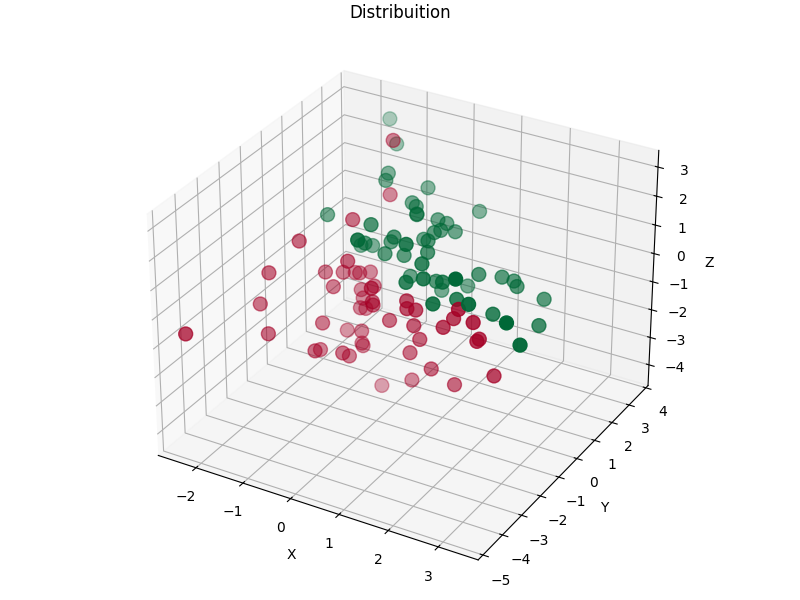

In [14]:
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': '3d'}, layout='constrained')
ax.scatter(
    X[:, 0],
    X[:, 1],
    X[:, 2],
    c=y,
    cmap="RdYlGn",
    marker="o",
    s=100
)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Distribuition')
plt.show()

In [25]:
cov_matrix = np.cov(X, rowvar=False)
cov_matrix

array([[ 1.60098   , -0.2409938 ,  0.20572454],
       [-0.2409938 ,  1.57931567,  0.55744678],
       [ 0.20572454,  0.55744678,  2.30355639]])

In [27]:
autovalores, autovetores = linalg.eig(cov_matrix)

In [28]:
autovalores

array([1.0882738 , 1.78478305, 2.6107952 ])

In [29]:
autovetores

array([[-0.51933038, -0.8517012 ,  0.07000732],
       [-0.74003681,  0.48918195,  0.46156965],
       [ 0.42736574, -0.18789915,  0.88433729]])

In [30]:
pares_auto = [(autovalores[i], autovetores[:, i]) for i in range(len(autovalores))]
pares_auto.sort(key=lambda x: x[0], reverse=True)

In [32]:
pares_auto[0]

(np.float64(2.610795200791229), array([0.07000732, 0.46156965, 0.88433729]))

In [33]:
# Extrair os autovetores ordenados
autovetores_ordenados = np.array([par[1] for par in pares_auto]).T

In [34]:
autovetores_ordenados

array([[ 0.07000732, -0.8517012 , -0.51933038],
       [ 0.46156965,  0.48918195, -0.74003681],
       [ 0.88433729, -0.18789915,  0.42736574]])

In [35]:
k = 2
matriz_componentes = autovetores_ordenados[:, :k]

In [36]:
matriz_componentes

array([[ 0.07000732, -0.8517012 ],
       [ 0.46156965,  0.48918195],
       [ 0.88433729, -0.18789915]])

In [38]:
X_pca = X.dot(matriz_componentes)

In [39]:
X_pca

array([[ 8.57578586e-01, -1.81308594e-01],
       [ 2.09172027e-01,  5.77058843e-01],
       [-4.76011122e-01,  8.39142635e-01],
       [ 9.43230890e-01, -3.47764163e+00],
       [-1.25010463e+00,  1.02372270e+00],
       [-1.53553646e+00,  9.77509741e-01],
       [-9.17950166e-01, -1.83664095e+00],
       [-2.82503812e+00,  1.96231650e-01],
       [-1.42684522e+00, -2.52608450e-01],
       [ 2.43241898e+00,  7.29745335e-01],
       [ 5.82307302e-01, -1.64403210e+00],
       [-2.12558983e+00,  6.02609041e-01],
       [-2.21822130e+00, -4.52122487e-01],
       [-3.17033532e-03,  9.26738410e-02],
       [-1.27385870e+00, -9.18412962e-01],
       [-2.73364044e+00, -1.14038800e+00],
       [ 1.75601681e-01, -1.09433548e+00],
       [-2.86788927e+00,  3.98426273e-01],
       [-7.08911740e-01, -1.28845250e+00],
       [-7.48086299e-01, -1.15683743e+00],
       [ 1.53518501e+00, -3.55046363e-01],
       [ 7.83181195e-01, -1.80963656e+00],
       [ 3.90139130e+00,  2.55467404e+00],
       [-2.

In [42]:
# Verifique a proporção de variância explicada por cada componente.
variancia_explicada = autovalores / np.sum(autovalores)
print("Variância explicada por componente:", variancia_explicada)

Variância explicada por componente: [0.19845061 0.32546156 0.47608783]


In [43]:
autovalores

array([1.0882738 , 1.78478305, 2.6107952 ])

In [44]:
from sklearn.decomposition import PCA

In [45]:
pca = PCA(n_components=2)

In [47]:
X_ = pca.fit_transform(X)

In [49]:
X_[0, :]

array([ 0.98737124, -0.28401883])

In [50]:
X_pca[0, :]

array([ 0.85757859, -0.18130859])

In [56]:
X_centered = X - np.mean(X, axis=0)

In [57]:
cov_matrix = np.cov(X_centered, rowvar=False)
cov_matrix

array([[ 1.60098   , -0.2409938 ,  0.20572454],
       [-0.2409938 ,  1.57931567,  0.55744678],
       [ 0.20572454,  0.55744678,  2.30355639]])

In [58]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
eigenvalues

array([1.0882738 , 1.78478305, 2.6107952 ])

In [59]:
eigenvectors

array([[ 0.51933038,  0.8517012 ,  0.07000732],
       [ 0.74003681, -0.48918195,  0.46156965],
       [-0.42736574,  0.18789915,  0.88433729]])

In [60]:
np.argsort(eigenvalues)

array([0, 1, 2])

In [62]:
idx = np.argsort(eigenvalues)[::-1]

In [63]:
eigenvalues[idx]

array([2.6107952 , 1.78478305, 1.0882738 ])

In [64]:
eigenvectors = eigenvectors[:, idx]

In [65]:
eigenvectors

array([[ 0.07000732,  0.8517012 ,  0.51933038],
       [ 0.46156965, -0.48918195,  0.74003681],
       [ 0.88433729,  0.18789915, -0.42736574]])

In [67]:
components = eigenvectors[:, :2]

In [68]:
components

array([[ 0.07000732,  0.8517012 ],
       [ 0.46156965, -0.48918195],
       [ 0.88433729,  0.18789915]])

In [69]:
X_centered @ components

array([[ 0.98737124, -0.28401883],
       [ 0.33896468, -1.04238626],
       [-0.34621847, -1.30447006],
       [ 1.07302355,  3.01231421],
       [-1.12031197, -1.48905012],
       [-1.4057438 , -1.44283716],
       [-0.78815751,  1.37131353],
       [-2.69524546, -0.66155907],
       [-1.29705257, -0.21271897],
       [ 2.56221164, -1.19507275],
       [ 0.71209996,  1.17870468],
       [-1.99579717, -1.06793646],
       [-2.08842864, -0.01320493],
       [ 0.12662232, -0.55800126],
       [-1.14406604,  0.45308554],
       [-2.60384779,  0.67506058],
       [ 0.30539434,  0.62900806],
       [-2.73809661, -0.86375369],
       [-0.57911908,  0.82312508],
       [-0.61829364,  0.69151001],
       [ 1.66497766, -0.11028106],
       [ 0.91297385,  1.34430914],
       [ 4.03118395, -3.02000146],
       [-2.45578123, -1.1763741 ],
       [ 2.07941976, -0.586191  ],
       [ 0.30640383,  1.34735586],
       [-2.49040883, -0.89086807],
       [ 0.05037871,  2.1888702 ],
       [-0.36553171,

In [51]:
import numpy as np

def pca_numpy(X, n_components=2):
    # 1) Centralizar os dados (tirar a média de cada feature)
    X_centered = X - np.mean(X, axis=0)
    
    # 2) Calcular a matriz de covariância
    cov_matrix = np.cov(X_centered, rowvar=False)
    
    # 3) Calcular autovalores e autovetores
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    # 4) Ordenar pelos maiores autovalores
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # 5) Selecionar os n_components principais
    components = eigenvectors[:, :n_components]
    
    # 6) Projetar os dados
    X_pca = X_centered @ components
    
    return X_pca, components, eigenvalues


In [55]:
X_[0, :]

array([ 0.98737124, -0.28401883])

In [53]:
pca_numpy(X)[0]

array([[ 0.98737124, -0.28401883],
       [ 0.33896468, -1.04238626],
       [-0.34621847, -1.30447006],
       [ 1.07302355,  3.01231421],
       [-1.12031197, -1.48905012],
       [-1.4057438 , -1.44283716],
       [-0.78815751,  1.37131353],
       [-2.69524546, -0.66155907],
       [-1.29705257, -0.21271897],
       [ 2.56221164, -1.19507275],
       [ 0.71209996,  1.17870468],
       [-1.99579717, -1.06793646],
       [-2.08842864, -0.01320493],
       [ 0.12662232, -0.55800126],
       [-1.14406604,  0.45308554],
       [-2.60384779,  0.67506058],
       [ 0.30539434,  0.62900806],
       [-2.73809661, -0.86375369],
       [-0.57911908,  0.82312508],
       [-0.61829364,  0.69151001],
       [ 1.66497766, -0.11028106],
       [ 0.91297385,  1.34430914],
       [ 4.03118395, -3.02000146],
       [-2.45578123, -1.1763741 ],
       [ 2.07941976, -0.586191  ],
       [ 0.30640383,  1.34735586],
       [-2.49040883, -0.89086807],
       [ 0.05037871,  2.1888702 ],
       [-0.36553171,